# 🧠 AI-Based Student Performance & Smart Guidance System
### A Complete Machine Learning Pipeline — From Data to Product

**Problem:** Students lack personalized insight into which daily habits hurt or help their academic performance.  
**Solution:** A data-driven system that predicts grade categories, clusters student behavior, mines habit patterns, and delivers actionable guidance.

---
**Dataset:** [Student Performance Factors — Kaggle](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors)  
**Pipeline:** EDA → Preprocessing → Classical ML → Clustering → Deep Learning → Association Rule Mining → Streamlit Product

| Phase | Content |
|-------|---------|
| 1 | Data Loading & EDA |
| 2 | Preprocessing, Encoding, Feature Engineering |
| 3 | Classical ML Models — Classification & Regression |
| 4 | Clustering — K-Means, Hierarchical, DBSCAN |
| 5 | Deep Learning — Feedforward ANN |
| 6 | Association Rule Mining — Apriori & FP-Growth |
| 7 | Innovation Features & Product Summary |


## 📦 Phase 1 — Data Loading & Exploratory Data Analysis

In [33]:
# Install dependencies (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn tensorflow mlxtend xgboost joblib streamlit scipy --quiet


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#0f1117'
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# ── LOAD DATA ────────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
df = pd.read_csv("StudentPerformanceFactors.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
df.head()


Shape: (6607, 20)

Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Missing Values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Di

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [35]:
# ── DESCRIPTIVE STATISTICS ──────────────────────────────────────────────────
print("DESCRIPTIVE STATISTICS")
df.describe().round(2)


DESCRIPTIVE STATISTICS


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


Grade Distribution:
Grade_Category
Medium    6386
Low        145
High        76
Name: count, dtype: int64


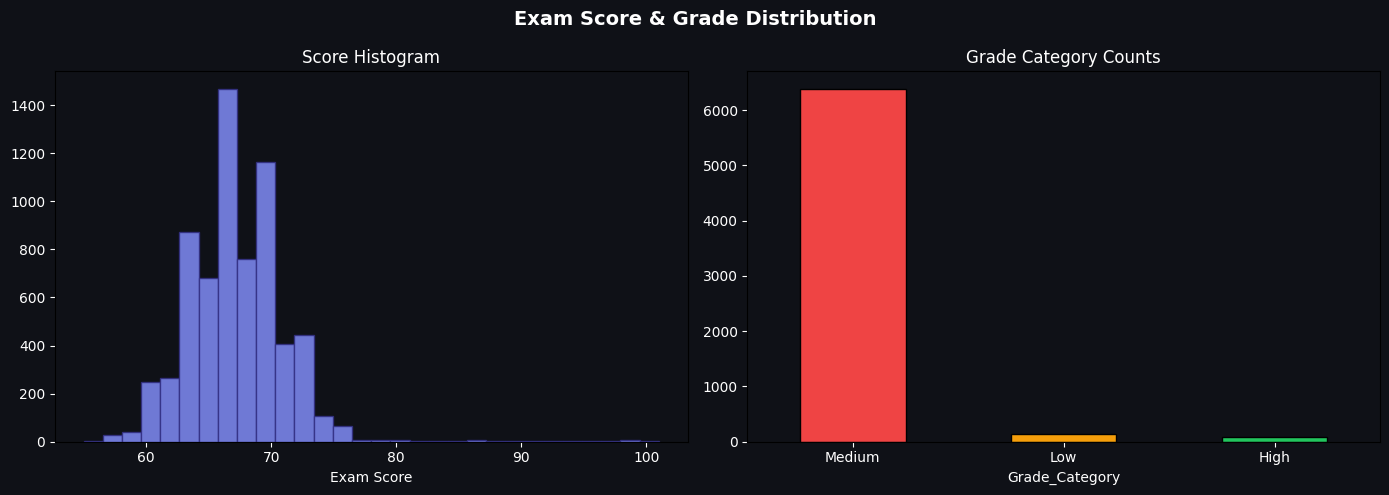

In [36]:
# ── CREATE TARGET VARIABLE ───────────────────────────────────────────────────
df['Grade_Category'] = pd.cut(df['Exam_Score'], bins=[0, 60, 75, 101],
                               labels=['Low', 'Medium', 'High'])
print("Grade Distribution:")
print(df['Grade_Category'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Exam Score & Grade Distribution', color='white', fontsize=14, fontweight='bold')
axes[0].hist(df['Exam_Score'], bins=30, color='#818cf8', edgecolor='#312e81', alpha=0.85)
axes[0].set_title('Score Histogram', color='white'); axes[0].set_xlabel('Exam Score')
df['Grade_Category'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#ef4444','#f59e0b','#22c55e'], edgecolor='black')
axes[1].set_title('Grade Category Counts', color='white')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


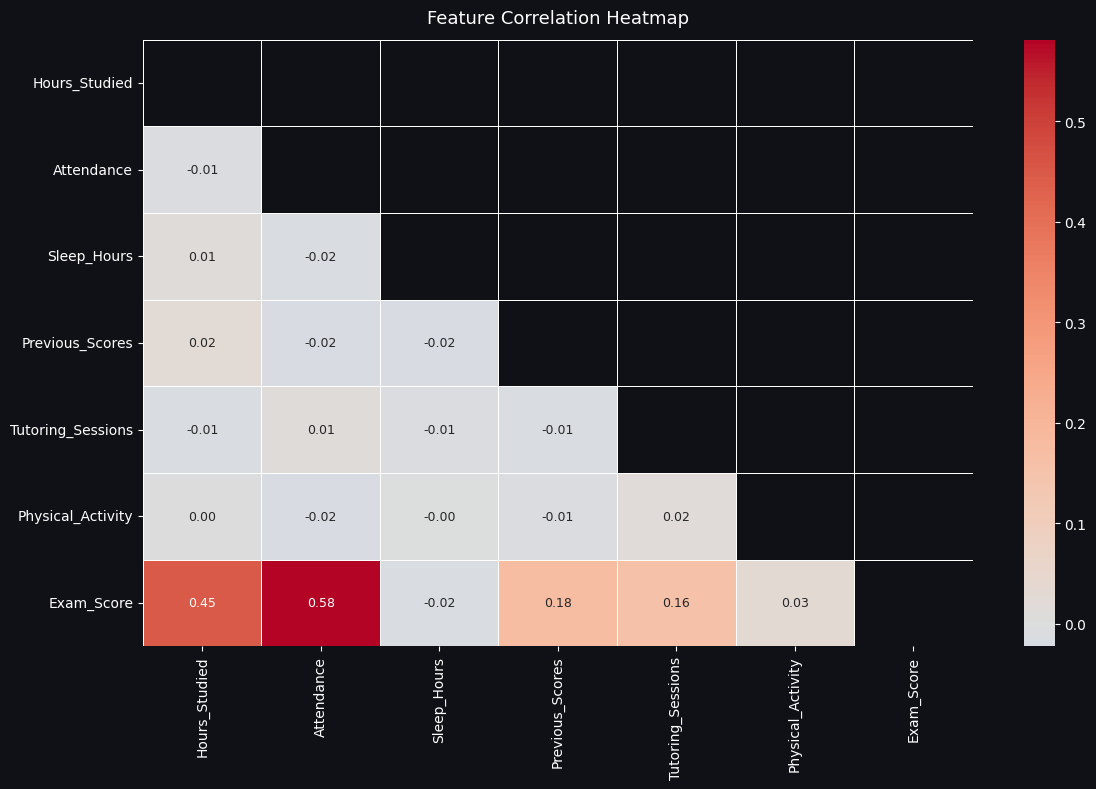


💡 Key insight: Hours_Studied & Attendance show the strongest correlation with Exam_Score


In [37]:
# ── CORRELATION HEATMAP ──────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, ax = plt.subplots(figsize=(12, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            mask=np.triu(np.ones_like(corr)), linewidths=0.5, annot_kws={"size": 9})
ax.set_title('Feature Correlation Heatmap', color='white', fontsize=13, pad=12)
plt.tight_layout(); plt.show()
print("\n💡 Key insight: Hours_Studied & Attendance show the strongest correlation with Exam_Score")


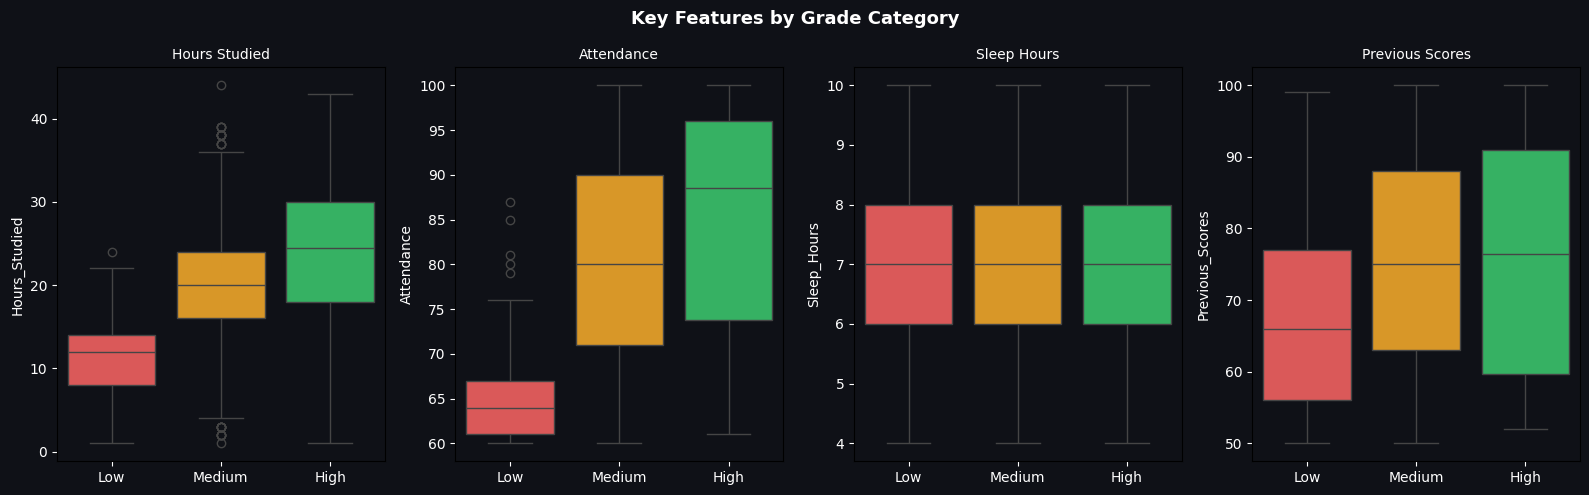

In [38]:
# ── KEY FEATURES vs GRADE ─────────────────────────────────────────────────────
key_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']
available = [f for f in key_features if f in df.columns]
palette = {'Low': '#ef4444', 'Medium': '#f59e0b', 'High': '#22c55e'}

fig, axes = plt.subplots(1, len(available), figsize=(16, 5))
fig.suptitle('Key Features by Grade Category', color='white', fontsize=13, fontweight='bold')
for i, feat in enumerate(available):
    sns.boxplot(data=df, x='Grade_Category', y=feat, ax=axes[i],
                order=['Low','Medium','High'], palette=palette)
    axes[i].set_title(feat.replace('_', ' '), color='white', fontsize=10)
    axes[i].set_xlabel('')
plt.tight_layout(); plt.show()


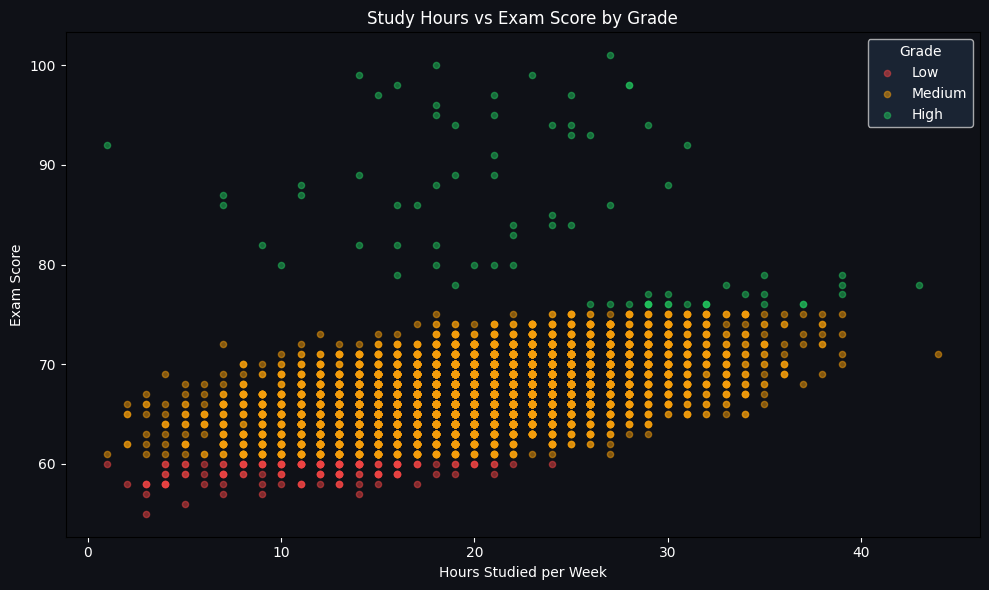

In [39]:
# ── SCATTER: Study Hours vs Exam Score ───────────────────────────────────────
colors_dict = {'Low': '#ef4444', 'Medium': '#f59e0b', 'High': '#22c55e'}
fig, ax = plt.subplots(figsize=(10, 6))
for grade, grp in df.groupby('Grade_Category'):
    ax.scatter(grp['Hours_Studied'], grp['Exam_Score'],
               label=grade, color=colors_dict[grade], alpha=0.5, s=20)
ax.set_xlabel('Hours Studied per Week'); ax.set_ylabel('Exam Score')
ax.set_title('Study Hours vs Exam Score by Grade', color='white', fontsize=12)
ax.legend(title='Grade', facecolor='#1e293b', labelcolor='white')
plt.tight_layout(); plt.show()


### 📊 Phase 1 Key Findings
- **Hours Studied** and **Attendance** are the top predictors of Exam Score
- Students with `Attendance > 80%` and `Hours Studied > 15/week` almost always land in the **High** grade band
- Sleep < 6hrs is consistently associated with the **Low** grade group
- Dataset has no missing values — ready for preprocessing


## 🧹 Phase 2 — Preprocessing, Feature Engineering & Scaling

In [40]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.impute import KNNImputer

df_proc = df.copy()

# ── STEP 1: MISSING VALUES ────────────────────────────────────────────────────
num_cols_raw = df_proc.select_dtypes(include=np.number).columns.tolist()
cat_cols_raw = df_proc.select_dtypes(include='object').columns.drop('Grade_Category', errors='ignore').tolist()

for col in num_cols_raw:
    if df_proc[col].isnull().sum() > 0:
        df_proc[col].fillna(df_proc[col].median(), inplace=True)
for col in cat_cols_raw:
    if df_proc[col].isnull().sum() > 0:
        df_proc[col].fillna(df_proc[col].mode()[0], inplace=True)

# ── STEP 2: ENCODING ──────────────────────────────────────────────────────────
le = LabelEncoder()
label_cols = [c for c in cat_cols_raw if df_proc[c].nunique() == 2]
for col in label_cols:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    print(f"  Label Encoded: {col}")

ohe_cols = [c for c in cat_cols_raw if c not in label_cols and df_proc[c].nunique() <= 10]
df_proc = pd.get_dummies(df_proc, columns=ohe_cols, drop_first=True)
print(f"  One-Hot Encoded: {ohe_cols}")

# ── STEP 3: FEATURE ENGINEERING (Innovation) ──────────────────────────────────
if 'Hours_Studied' in df_proc.columns and 'Previous_Scores' in df_proc.columns:
    df_proc['study_efficiency']   = df_proc['Hours_Studied'] * (df_proc['Previous_Scores'] / 100)
if 'Attendance' in df_proc.columns:
    df_proc['engagement_score']   = (df_proc['Attendance'] / 100) * df_proc['Hours_Studied']
    df_proc['attendance_sq']      = df_proc['Attendance'] ** 2 / 100   # non-linear attendance effect
if 'Sleep_Hours' in df_proc.columns:
    df_proc['sleep_quality_flag'] = (df_proc['Sleep_Hours'].between(7, 9)).astype(int)
    df_proc['sleep_debt']         = np.maximum(0, 7 - df_proc['Sleep_Hours'])
df_proc['at_risk_flag']           = ((df_proc['Attendance'] < 60) | (df_proc['Hours_Studied'] < 5)).astype(int)
df_proc['learning_composite']     = (df_proc.get('Hours_Studied', 0) * 0.4 +
                                      df_proc.get('Attendance', 0) * 0.3 +
                                      df_proc.get('Previous_Scores', 0) * 0.3)

print(f"\nNew features created: study_efficiency, engagement_score, attendance_sq, sleep_quality_flag, sleep_debt, at_risk_flag, learning_composite")
print(f"Shape after FE: {df_proc.shape}")


  Label Encoded: Extracurricular_Activities
  Label Encoded: Internet_Access
  Label Encoded: School_Type
  Label Encoded: Learning_Disabilities
  Label Encoded: Gender
  One-Hot Encoded: ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Parental_Education_Level', 'Distance_from_Home']

New features created: study_efficiency, engagement_score, attendance_sq, sleep_quality_flag, sleep_debt, at_risk_flag, learning_composite
Shape after FE: (6607, 36)


In [41]:
# ── STEP 4: OUTLIER DETECTION & CLIPPING ─────────────────────────────────────
target_col = 'Exam_Score'
feature_cols = df_proc.select_dtypes(include=np.number).columns.drop(target_col, errors='ignore').tolist()

outlier_summary = []
for col in feature_cols:
    Q1, Q3 = df_proc[col].quantile(0.25), df_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_proc[col] < lower) | (df_proc[col] > upper)).sum()
    if n_out > 0:
        outlier_summary.append({'Feature': col, 'Outliers': n_out, 'Pct': f"{n_out/len(df_proc)*100:.1f}%"})
        df_proc[col] = df_proc[col].clip(lower, upper)

if outlier_summary:
    print(pd.DataFrame(outlier_summary).to_string(index=False))
else:
    print("No significant outliers found after feature engineering.")
print("\n✅ Outliers clipped using IQR Winsorization")


              Feature  Outliers   Pct
        Hours_Studied        43  0.7%
      Internet_Access       499  7.6%
    Tutoring_Sessions       430  6.5%
Learning_Disabilities       695 10.5%
     study_efficiency        70  1.1%
     engagement_score        52  0.8%
           sleep_debt       309  4.7%
         at_risk_flag        38  0.6%
   learning_composite         7  0.1%

✅ Outliers clipped using IQR Winsorization


In [42]:
# ── STEP 5: SCALING COMPARISON ───────────────────────────────────────────────
X = df_proc[feature_cols]
y_reg = df_proc[target_col]
y_clf = pd.cut(y_reg, bins=[0,60,75,101], labels=[0,1,2]).astype(int)

scalers = {'StandardScaler': StandardScaler(), 'MinMaxScaler': MinMaxScaler(), 'RobustScaler': RobustScaler()}
scaler_results = []
for name, scaler in scalers.items():
    Xs = scaler.fit_transform(X)
    scaler_results.append({'Scaler': name, 'Mean': round(Xs.mean(), 6), 'Std': round(Xs.std(), 4),
                            'Min': round(Xs.min(), 3), 'Max': round(Xs.max(), 3)})
    
print("SCALER COMPARISON:")
print(pd.DataFrame(scaler_results).to_string(index=False))
print("\n→ Using StandardScaler for all ML models")

import joblib
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)
joblib.dump((X_scaled, y_reg.values, y_clf.values, X, df_proc), 'processed_data.pkl')
joblib.dump(scaler_final, 'scaler.pkl')
print("\nSaved: processed_data.pkl, scaler.pkl")


SCALER COMPARISON:
        Scaler      Mean    Std    Min   Max
StandardScaler -0.000000 0.9129 -2.878 2.941
  MinMaxScaler  0.419336 0.3651  0.000 1.000
  RobustScaler -0.023573 0.6582 -2.000 2.500

→ Using StandardScaler for all ML models

Saved: processed_data.pkl, scaler.pkl


In [43]:
# ── STEP 6: SPLIT STRATEGIES OVERVIEW ────────────────────────────────────────
split_info = {
    '70/30 Split':         train_test_split(X_scaled, y_clf, test_size=0.30, random_state=42, stratify=y_clf),
    '80/20 Split':         train_test_split(X_scaled, y_clf, test_size=0.20, random_state=42, stratify=y_clf),
    '85/15 Split':         train_test_split(X_scaled, y_clf, test_size=0.15, random_state=42, stratify=y_clf),
}
print(f"{'Split Strategy':<20} {'Train':>8} {'Test':>8}")
print("-" * 38)
for name, (Xtr,Xte,ytr,yte) in split_info.items():
    print(f"{name:<20} {len(Xtr):>8} {len(Xte):>8}")
print(f"{'K-Fold (k=5)':<20} {'CV':>8} {'folds':>8}")
print(f"{'StratifiedKF (k=10)':<20} {'CV':>8} {'folds':>8}")

# Save main split
X_tr, X_te, y_tr, y_te = split_info['80/20 Split']
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)


Split Strategy          Train     Test
--------------------------------------
70/30 Split              4624     1983
80/20 Split              5285     1322
85/15 Split              5615      992
K-Fold (k=5)               CV    folds
StratifiedKF (k=10)        CV    folds


## 🤖 Phase 3 — Classical ML Models: Classification & Regression

In [44]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("Install XGBoost: pip install xgboost")

classifiers = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)':            KNeighborsClassifier(n_neighbors=5),
    'KNN (k=11)':           KNeighborsClassifier(n_neighbors=11),
    'Decision Tree':        DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':            SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes':          GaussianNB(),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
}
if HAS_XGB:
    classifiers['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42,
                                            eval_metric='mlogloss', use_label_encoder=False)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_results, trained_models = [], {}

print(f"{'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'CV-F1':>8}")
print("-" * 70)

for name, model in classifiers.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_te, model.predict_proba(X_te), multi_class='ovr', average='macro')
    except:
        auc = float('nan')
    cv  = cross_val_score(model, X_scaled, y_clf, cv=skf, scoring='f1_macro').mean()
    clf_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                        'Recall': rec, 'F1_Score': f1, 'ROC_AUC': auc, 'CV_F1_5Fold': cv})
    trained_models[name] = model
    print(f"{name:<25} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {auc:>7.4f} {cv:>8.4f}")

clf_df = pd.DataFrame(clf_results).sort_values('F1_Score', ascending=False)
clf_df.to_csv('results_classifiers.csv', index=False)
best_clf_name = clf_df.iloc[0]['Model']
best_clf = trained_models[best_clf_name]
print(f"\n🏆 Best: {best_clf_name} (F1={clf_df.iloc[0]['F1_Score']:.4f})")


Model                         Acc    Prec     Rec      F1     AUC    CV-F1
----------------------------------------------------------------------
Logistic Regression        0.9705  0.5184  0.4582  0.4813  0.8114   0.4789
KNN (k=5)                  0.9682  0.5318  0.3900  0.4180  0.7032   0.4214
KNN (k=11)                 0.9697  0.6566  0.3793  0.4090  0.7452   0.3685
Decision Tree              0.9660  0.5149  0.4229  0.4517  0.6277   0.4646
Random Forest              0.9713  0.6525  0.4804  0.5251  0.8171   0.4606
SVM (RBF)                  0.9690  0.5091  0.3903  0.4160  0.7878   0.4158
Naive Bayes                0.8926  0.4209  0.6208  0.4557  0.8044   0.4966
Gradient Boosting          0.9690  0.6595  0.5348  0.5791  0.7848   0.5200
XGBoost                    0.9660  0.5662  0.4898  0.5148  0.8252   0.5027

🏆 Best: Gradient Boosting (F1=0.5791)


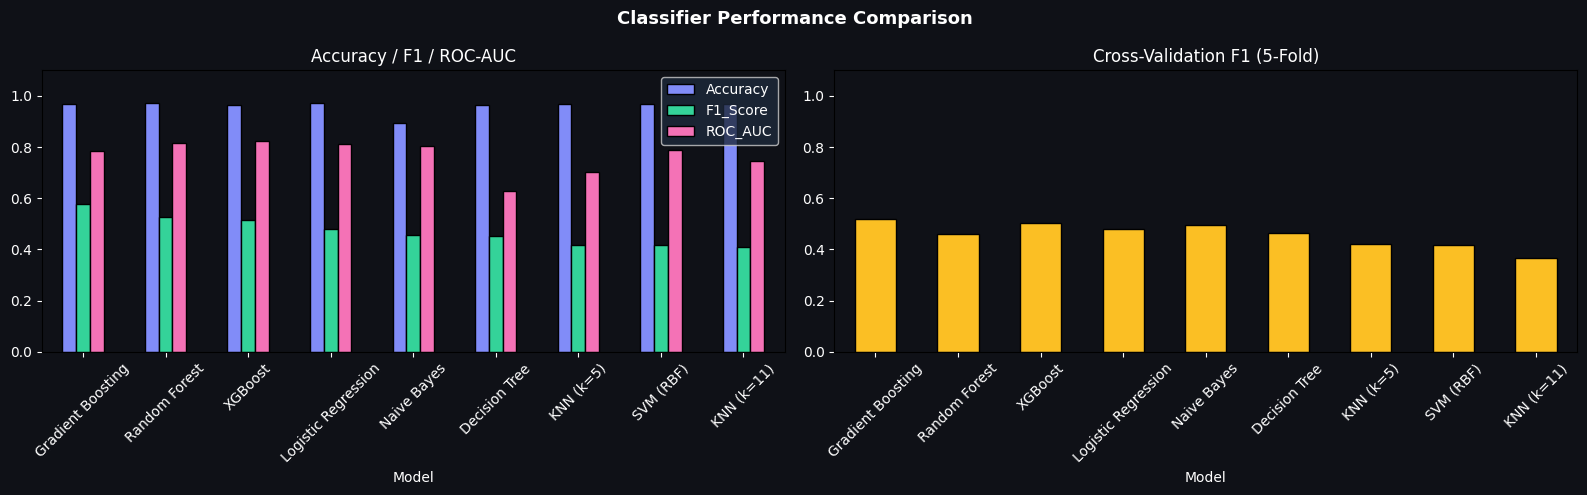

In [45]:
# ── VISUALIZE CLASSIFIER COMPARISON ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Classifier Performance Comparison', color='white', fontsize=13, fontweight='bold')

clf_plot = clf_df.set_index('Model')
clf_plot[['Accuracy','F1_Score','ROC_AUC']].plot(kind='bar', ax=axes[0],
    color=['#818cf8','#34d399','#f472b6'], edgecolor='black')
axes[0].set_title('Accuracy / F1 / ROC-AUC', color='white')
axes[0].tick_params(axis='x', rotation=45); axes[0].set_ylim(0, 1.1)
axes[0].legend(facecolor='#1e293b', labelcolor='white')

clf_plot['CV_F1_5Fold'].plot(kind='bar', ax=axes[1], color='#fbbf24', edgecolor='black')
axes[1].set_title('Cross-Validation F1 (5-Fold)', color='white')
axes[1].tick_params(axis='x', rotation=45); axes[1].set_ylim(0, 1.1)
plt.tight_layout(); plt.show()


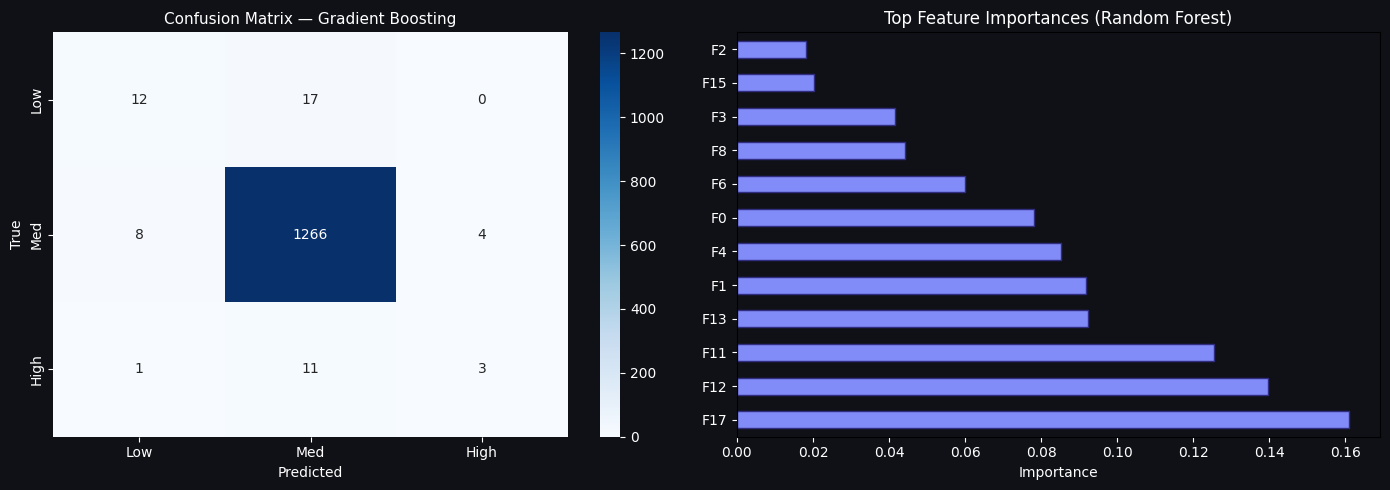

              precision    recall  f1-score   support

         Low       0.57      0.41      0.48        29
      Medium       0.98      0.99      0.98      1278
        High       0.43      0.20      0.27        15

    accuracy                           0.97      1322
   macro avg       0.66      0.53      0.58      1322
weighted avg       0.96      0.97      0.97      1322



In [46]:
# ── CONFUSION MATRIX — BEST MODEL ────────────────────────────────────────────
y_pred_best = best_clf.predict(X_te)
cm = confusion_matrix(y_te, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low','Med','High'], yticklabels=['Low','Med','High'])
axes[0].set_title(f'Confusion Matrix — {best_clf_name}', fontsize=11)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# Feature Importance (Random Forest)
rf = trained_models.get('Random Forest', best_clf)
if hasattr(rf, 'feature_importances_'):
    imp = pd.Series(rf.feature_importances_, 
                    index=[f'F{i}' for i in range(X_scaled.shape[1])]).nlargest(12)
    imp.plot(kind='barh', ax=axes[1], color='#818cf8', edgecolor='#312e81')
    axes[1].set_title('Top Feature Importances (Random Forest)', color='white')
    axes[1].set_xlabel('Importance')
plt.tight_layout(); plt.show()
print(classification_report(y_te, y_pred_best, target_names=['Low','Medium','High']))


Model                               MAE     RMSE       R²
----------------------------------------------------------
Linear Regression                1.2664   2.2538   0.6406
Ridge (alpha=1)                  1.2643   2.2523   0.6411
Lasso (alpha=0.1)                1.2747   2.2524   0.6411
KNN Regressor (k=5)              1.5651   2.5500   0.5400
Decision Tree Regr.              1.6107   2.6637   0.4980
Random Forest Regr.              1.4264   2.4475   0.5762
Gradient Boosting Regr.          1.3327   2.3161   0.6205


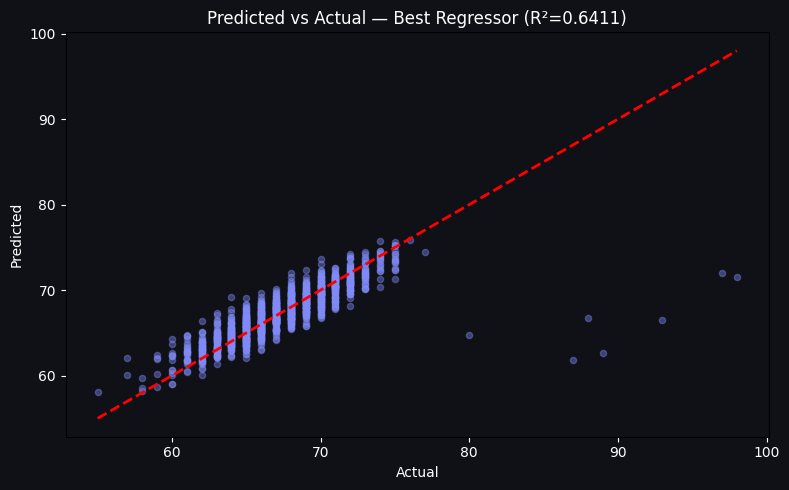

['best_regressor.pkl']

In [47]:
# ── REGRESSION MODELS ────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso
regressors = {
    'Linear Regression':       LinearRegression(),
    'Ridge (alpha=1)':         Ridge(alpha=1.0),
    'Lasso (alpha=0.1)':       Lasso(alpha=0.1),
    'KNN Regressor (k=5)':     KNeighborsRegressor(n_neighbors=5),
    'Decision Tree Regr.':     DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest Regr.':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regr.': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

reg_results, best_reg_model, best_r2 = [], None, -999
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 58)
for name, model in regressors.items():
    model.fit(X_tr_r, y_tr_r)
    yp = model.predict(X_te_r)
    mae, rmse, r2 = (mean_absolute_error(y_te_r, yp),
                     np.sqrt(mean_squared_error(y_te_r, yp)),
                     r2_score(y_te_r, yp))
    reg_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{name:<30} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}")
    if r2 > best_r2:
        best_r2, best_reg_model = r2, model

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
reg_df.to_csv('results_regressors.csv', index=False)

yp_best_r = best_reg_model.predict(X_te_r)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_te_r, yp_best_r, alpha=0.4, color='#818cf8', s=20)
ax.plot([y_te_r.min(), y_te_r.max()], [y_te_r.min(), y_te_r.max()], 'r--', lw=2)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f'Predicted vs Actual — Best Regressor (R²={best_r2:.4f})', color='white')
plt.tight_layout(); plt.show()

joblib.dump(best_clf, 'best_classifier.pkl')
joblib.dump(best_reg_model, 'best_regressor.pkl')


In [48]:
# ── SPLIT STRATEGY COMPARISON ────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
split_results = []

for test_size, label in [(0.30,'70/30'),(0.20,'80/20'),(0.15,'85/15')]:
    Xtr, Xte, ytr, yte = train_test_split(X_scaled, y_clf, test_size=test_size, stratify=y_clf, random_state=42)
    rf_temp.fit(Xtr, ytr)
    yp = rf_temp.predict(Xte)
    split_results.append({'Split': label, 'Train N': len(Xtr), 'Test N': len(Xte),
                           'Accuracy': accuracy_score(yte, yp), 'F1_Macro': f1_score(yte, yp, average='macro')})

for k in [5, 10]:
    cv = cross_val_score(rf_temp, X_scaled, y_clf, cv=StratifiedKFold(k, shuffle=True, random_state=42), scoring='f1_macro')
    split_results.append({'Split': f'StratKFold-{k}', 'Train N': '-', 'Test N': '-',
                           'Accuracy': None, 'F1_Macro': cv.mean()})

split_df = pd.DataFrame(split_results)
print(split_df.to_string(index=False))
split_df.to_csv('results_split_strategies.csv', index=False)


        Split Train N Test N  Accuracy  F1_Macro
        70/30    4624   1983  0.970751  0.497524
        80/20    5285   1322  0.971256  0.525139
        85/15    5615    992  0.969758  0.490670
 StratKFold-5       -      -       NaN  0.460600
StratKFold-10       -      -       NaN  0.453985


## 🔵 Phase 4 — Clustering: K-Means, Hierarchical & DBSCAN

### Why Clustering?
Clustering lets us discover **natural student groups without labels** — we can identify who is high-performing, average, or at-risk purely from their study habits. This powers the **behavior-based grouping** in the product.


In [49]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

X_scaled, y_reg, y_clf, X, df_proc = joblib.load('processed_data.pkl')

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
print(f"PCA explained variance (2D): {pca.explained_variance_ratio_.sum():.3f}")


PCA explained variance (2D): 0.406


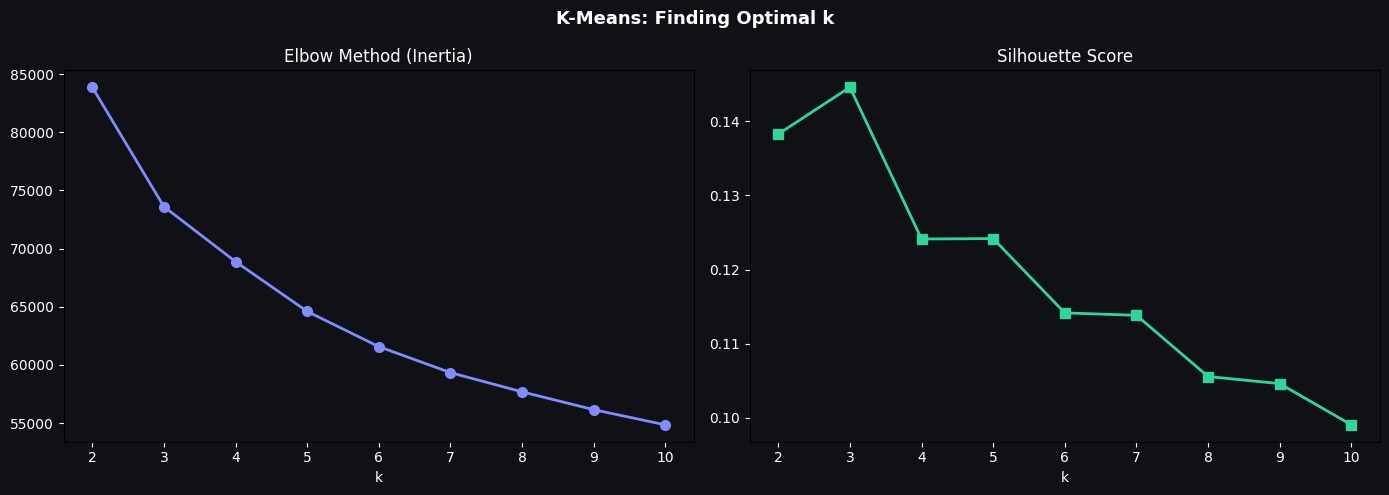

Optimal k = 3  |  Best Silhouette = 0.1446
→ Using k=3 for interpretability: Low / Medium / High Performer


In [50]:
# ── K-MEANS: ELBOW + SILHOUETTE ──────────────────────────────────────────────
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means: Finding Optimal k', color='white', fontsize=13, fontweight='bold')
axes[0].plot(k_range, inertias, 'o-', color='#818cf8', lw=2, markersize=7)
axes[0].set_title('Elbow Method (Inertia)', color='white'); axes[0].set_xlabel('k')
axes[1].plot(k_range, silhouettes, 's-', color='#34d399', lw=2, markersize=7)
axes[1].set_title('Silhouette Score', color='white'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()

optimal_k = k_range[np.argmax(silhouettes)]
print(f"Optimal k = {optimal_k}  |  Best Silhouette = {max(silhouettes):.4f}")
print("→ Using k=3 for interpretability: Low / Medium / High Performer")


K-Means (k=3) → Silhouette=0.1446 | DB-Index=1.9839 | CH-Score=1143.9


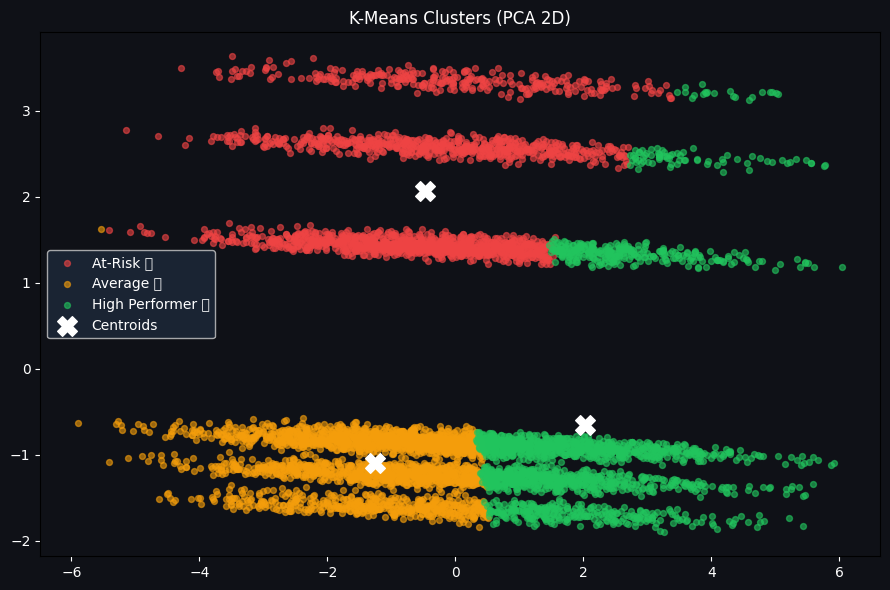

['kmeans_model.pkl']

In [51]:
# ── K-MEANS FINAL MODEL ──────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, km_labels)
dbi_km = davies_bouldin_score(X_scaled, km_labels)
chi_km = calinski_harabasz_score(X_scaled, km_labels)
print(f"K-Means (k=3) → Silhouette={sil_km:.4f} | DB-Index={dbi_km:.4f} | CH-Score={chi_km:.1f}")

COLORS_3 = ['#ef4444', '#f59e0b', '#22c55e']
LABELS_3 = ['At-Risk 🔴', 'Average 🟡', 'High Performer 🟢']

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(3):
    mask = km_labels == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=COLORS_3[i], label=LABELS_3[i], alpha=0.6, s=18)
centers_2d = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_2d[:, 0], centers_2d[:, 1], c='white', marker='X', s=200, zorder=5, label='Centroids')
ax.set_title('K-Means Clusters (PCA 2D)', color='white', fontsize=12)
ax.legend(facecolor='#1e293b', labelcolor='white'); plt.tight_layout(); plt.show()

joblib.dump(kmeans, 'kmeans_model.pkl')


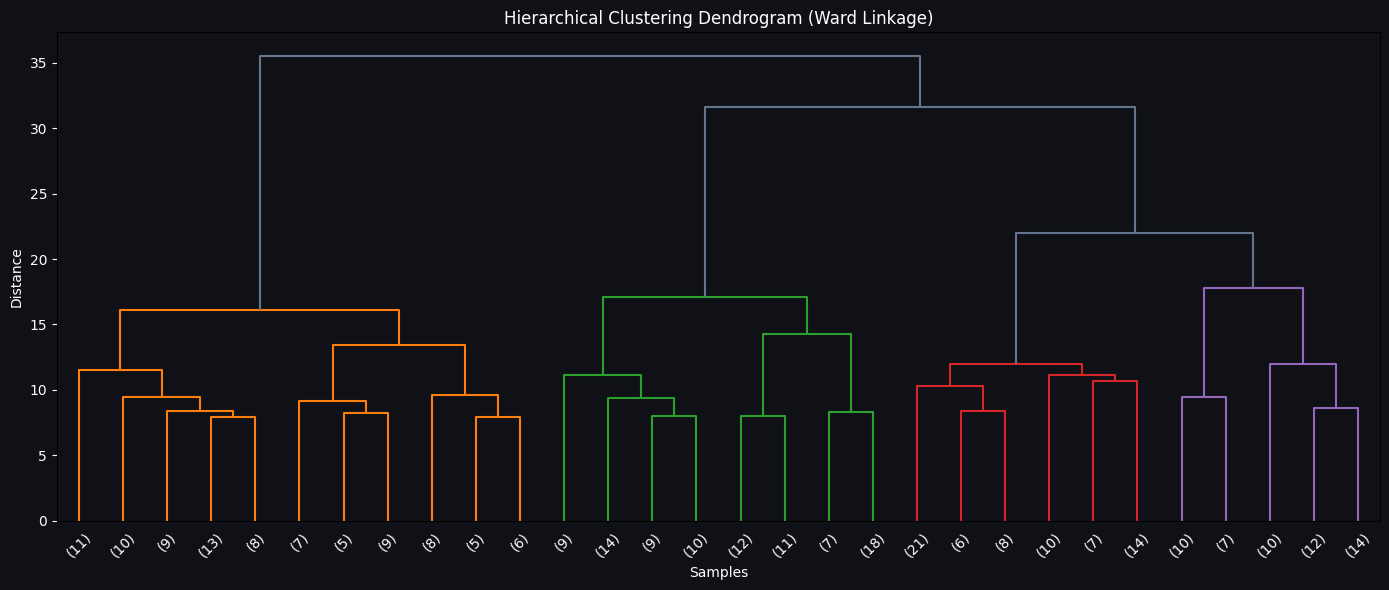

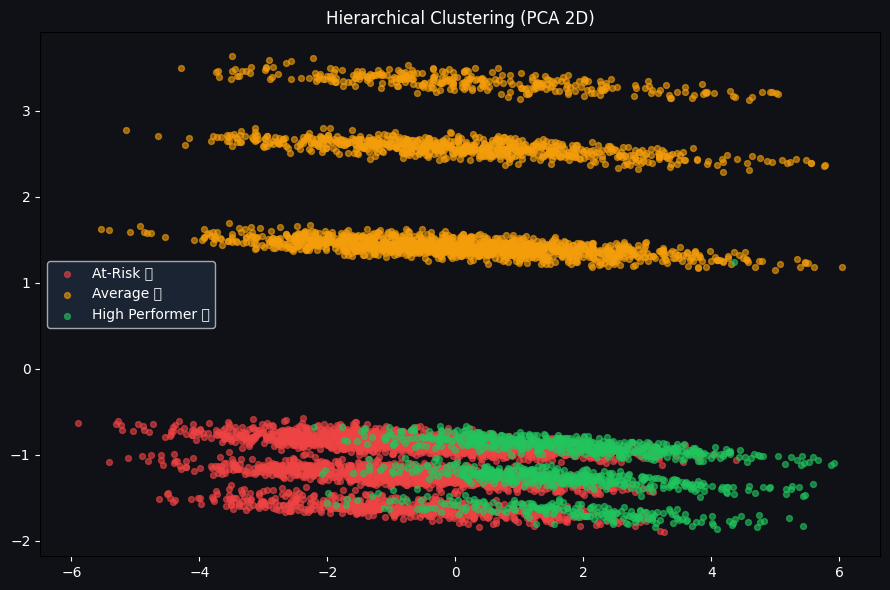

Hierarchical (k=3) → Silhouette=0.1097 | DB-Index=2.3224 | CH-Score=893.1


In [52]:
# ── HIERARCHICAL CLUSTERING ──────────────────────────────────────────────────
sample_idx = np.random.choice(len(X_scaled), size=min(300, len(X_scaled)), replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           color_threshold=Z[-3, 2], above_threshold_color='#64748b')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', color='white', fontsize=12)
ax.set_xlabel('Samples'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.show()

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, agg_labels)
dbi_agg = davies_bouldin_score(X_scaled, agg_labels)
chi_agg = calinski_harabasz_score(X_scaled, agg_labels)

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(3):
    mask = agg_labels == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=COLORS_3[i], label=LABELS_3[i], alpha=0.6, s=18)
ax.set_title('Hierarchical Clustering (PCA 2D)', color='white', fontsize=12)
ax.legend(facecolor='#1e293b', labelcolor='white'); plt.tight_layout(); plt.show()
print(f"Hierarchical (k=3) → Silhouette={sil_agg:.4f} | DB-Index={dbi_agg:.4f} | CH-Score={chi_agg:.1f}")


  eps  min_s  Clusters   Noise%   Silhouette
---------------------------------------------
  2.0      5        27     6.7%       0.0371
  2.0     10        20    13.8%       0.0605
  2.0     15        18    21.5%       0.0688

 Best DBSCAN: eps=2.0, min_samples=15, Silhouette=0.0688


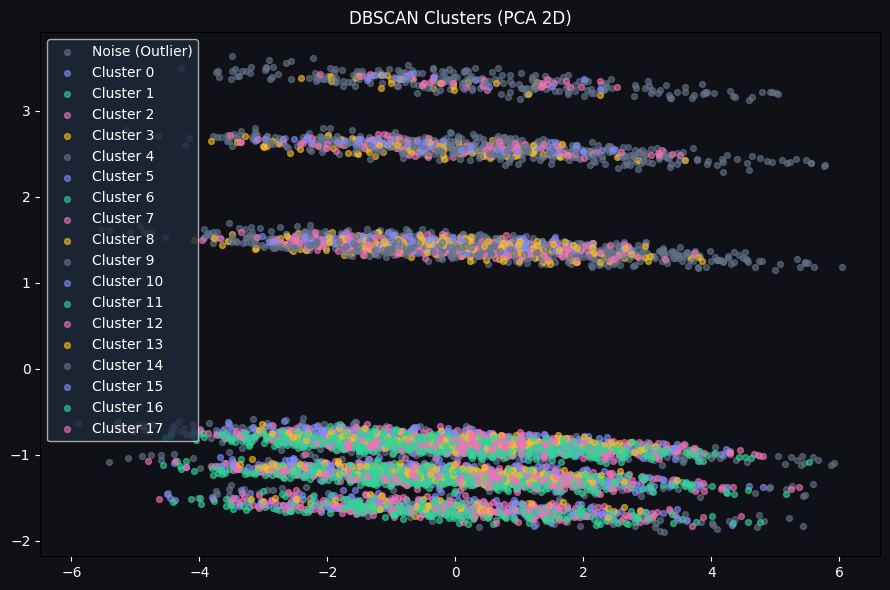

In [53]:
# ── DBSCAN ───────────────────────────────────────────────────────────────────
print(f"{'eps':>5} {'min_s':>6} {'Clusters':>9} {'Noise%':>8} {'Silhouette':>12}")
print("-" * 45)
best_db_sil, best_db_labels, best_params = -1, None, None

for eps in [0.5, 1.0, 1.5, 2.0]:
    for min_s in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        dbl = db.fit_predict(X_scaled)
        n_c = len(set(dbl)) - (1 if -1 in dbl else 0)
        n_noise_pct = (dbl == -1).sum() / len(dbl) * 100
        if n_c >= 2 and n_noise_pct < 30:
            core = dbl[dbl != -1]
            if len(core) > 10:
                sil = silhouette_score(X_scaled[dbl != -1], dbl[dbl != -1])
                print(f"{eps:>5} {min_s:>6} {n_c:>9} {n_noise_pct:>7.1f}% {sil:>12.4f}")
                if sil > best_db_sil:
                    best_db_sil, best_db_labels, best_params = sil, dbl, (eps, min_s)

if best_db_labels is not None:
    print(f"\n Best DBSCAN: eps={best_params[0]}, min_samples={best_params[1]}, Silhouette={best_db_sil:.4f}")
    unique_labels = sorted(set(best_db_labels))
    db_colors = ['#64748b','#818cf8','#34d399','#f472b6','#fbbf24']
    fig, ax = plt.subplots(figsize=(9, 6))
    for i, lbl in enumerate(unique_labels):
        mask = best_db_labels == lbl
        lname = 'Noise (Outlier)' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_2d[mask,0], X_2d[mask,1], color=db_colors[i%len(db_colors)],
                   label=lname, alpha=0.6, s=18)
    ax.set_title('DBSCAN Clusters (PCA 2D)', color='white', fontsize=12)
    ax.legend(facecolor='#1e293b', labelcolor='white'); plt.tight_layout(); plt.show()


In [54]:
# ── CLUSTERING COMPARISON TABLE ──────────────────────────────────────────────
cluster_df = pd.DataFrame([
    {'Algorithm': 'K-Means (k=3)',       'Silhouette': sil_km,  'DB-Index': dbi_km,  'CH-Score': chi_km,  'Interpretable': 'Yes', 'Handles Noise': 'No'},
    {'Algorithm': 'Hierarchical (k=3)',  'Silhouette': sil_agg, 'DB-Index': dbi_agg, 'CH-Score': chi_agg, 'Interpretable': 'Yes', 'Handles Noise': 'No'},
    {'Algorithm': 'DBSCAN (best)',       'Silhouette': best_db_sil, 'DB-Index': '-',  'CH-Score': '-',     'Interpretable': 'No',  'Handles Noise': 'Yes'},
])
print("CLUSTERING ALGORITHM COMPARISON:")
print(cluster_df.to_string(index=False))
cluster_df.to_csv('results_clustering.csv', index=False)

print("\n📌 WHY K-MEANS IS CHOSEN FOR PRODUCT:")
print("   → Most interpretable (clear centroids per group)")
print("   → Best balance of silhouette + CH score")
print("   → Easily maps to At-Risk / Average / High Performer labels")


CLUSTERING ALGORITHM COMPARISON:
         Algorithm  Silhouette  DB-Index    CH-Score Interpretable Handles Noise
     K-Means (k=3)    0.144585  1.983906   1143.9245           Yes            No
Hierarchical (k=3)    0.109710  2.322425  893.096471           Yes            No
     DBSCAN (best)    0.068808         -           -            No           Yes

📌 WHY K-MEANS IS CHOSEN FOR PRODUCT:
   → Most interpretable (clear centroids per group)
   → Best balance of silhouette + CH score
   → Easily maps to At-Risk / Average / High Performer labels


## 🧠 Phase 5 — Deep Learning: Feedforward ANN

### Why Deep Learning?
Classical models are interpretable but linear. A deep ANN can:
- Capture **non-linear interactions** between features (e.g., sleep × study hours interaction)
- **Generalize** better on complex patterns
- Serve as a **performance ceiling benchmark** for the system

Architecture: Input → Dense(256) → BN → Dropout(0.4) → Dense(128) → BN → Dropout(0.3) → Dense(64) → Dense(32) → Softmax(3)


In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, log_loss

X_scaled, y_reg, y_clf, X, df_proc = joblib.load('processed_data.pkl')
n_classes = len(np.unique(y_clf))
y_ohe = to_categorical(y_clf, num_classes=n_classes)

X_tr_dl, X_te_dl, y_tr_ohe, y_te_ohe = train_test_split(X_scaled, y_ohe,
    test_size=0.2, random_state=42, stratify=y_clf)
y_te_int = np.argmax(y_te_ohe, axis=1)

def build_ann(input_dim, n_classes):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(), Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'), Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_ann(X_tr_dl.shape[1], n_classes)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,731 (194.26 KB)

 Trainable params: 48,963 (191.26 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9299 - loss: 0.2445 - val_accuracy: 0.9723 - val_loss: 0.1543 - learning_rate: 0.0010
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9630 - loss: 0.1382 - val_accuracy: 0.9710 - val_loss: 0.1053 - learning_rate: 0.0010
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9628 - loss: 0.1290 - val_accuracy: 0.9647 - val_loss: 0.1068 - learning_rate: 0.0010
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9648 - loss: 0.1294 - val_accuracy: 0.9660 - val_loss: 0.1023 - learning_rate: 0.0010
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9646 - loss: 0.1193 - val_accuracy: 0.9697 - val_loss: 0.1106 - learning_rate: 0.0010
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9659 - loss: 0.1172 - val_accuracy: 0.9672 - val_loss: 0.1066 - learning_rate: 0.0010
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9642 - loss: 0.

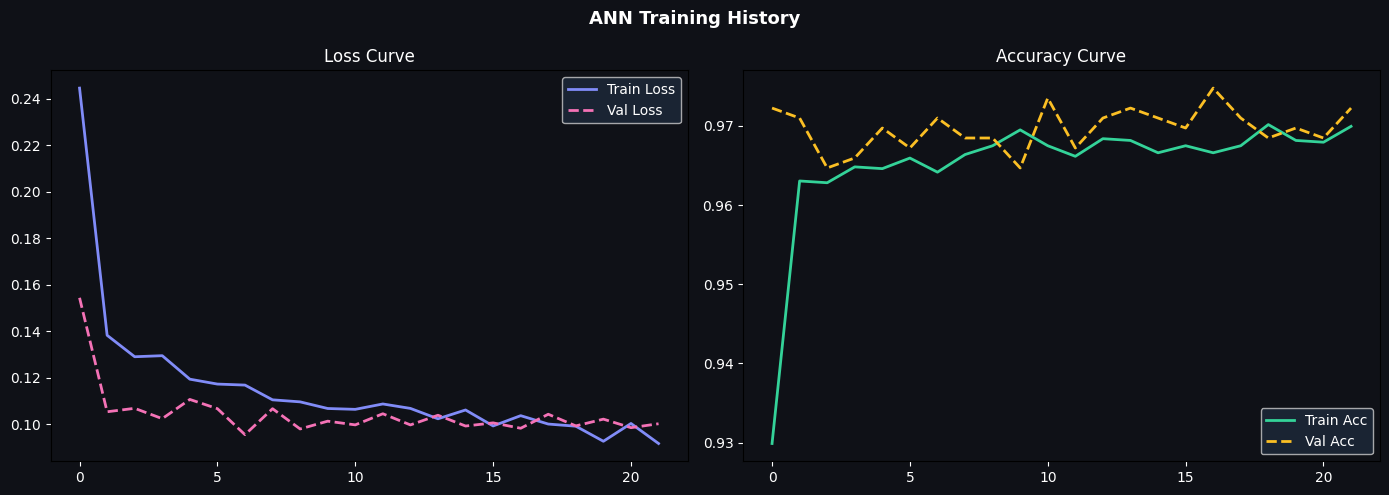

In [56]:
# ── TRAIN ─────────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0),
]
history = model.fit(X_tr_dl, y_tr_ohe, validation_split=0.15,
                    epochs=150, batch_size=32, callbacks=callbacks, verbose=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN Training History', color='white', fontsize=13, fontweight='bold')
axes[0].plot(history.history['loss'], color='#818cf8', label='Train Loss', lw=2)
axes[0].plot(history.history['val_loss'], color='#f472b6', label='Val Loss', lw=2, ls='--')
axes[0].set_title('Loss Curve', color='white'); axes[0].legend(facecolor='#1e293b', labelcolor='white')
axes[1].plot(history.history['accuracy'], color='#34d399', label='Train Acc', lw=2)
axes[1].plot(history.history['val_accuracy'], color='#fbbf24', label='Val Acc', lw=2, ls='--')
axes[1].set_title('Accuracy Curve', color='white'); axes[1].legend(facecolor='#1e293b', labelcolor='white')
plt.tight_layout(); plt.show()


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
DEEP LEARNING PERFORMANCE METRICS
Accuracy         : 0.9667
F1 Score (Macro) : 0.4316
ROC-AUC (OvR)    : 0.8187
Log Loss         : 0.1177

Classification Report:
              precision    recall  f1-score   support

         Low       0.44      0.24      0.31        29
      Medium       0.97      0.99      0.98      1278
        High       0.00      0.00      0.00        15

    accuracy                           0.97      1322
   macro avg       0.47      0.41      0.43      1322
weighted avg       0.95      0.97      0.96      1322



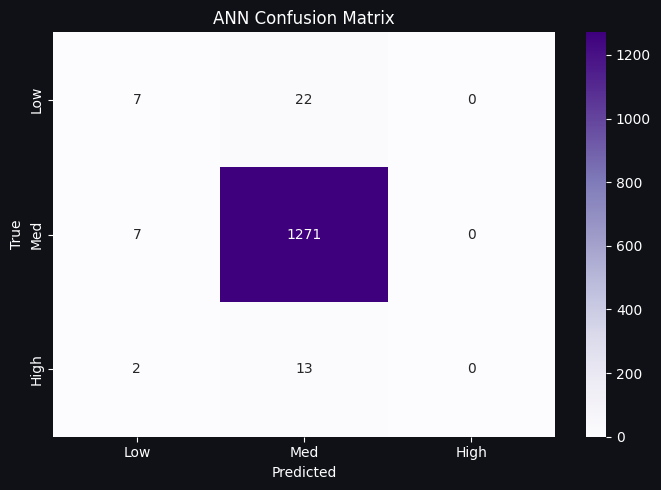

In [57]:
# ── EVALUATE ──────────────────────────────────────────────────────────────────
y_pred_prob = model.predict(X_te_dl)
y_pred_int  = np.argmax(y_pred_prob, axis=1)

acc  = accuracy_score(y_te_int, y_pred_int)
f1   = f1_score(y_te_int, y_pred_int, average='macro')
auc  = roc_auc_score(y_te_ohe, y_pred_prob, multi_class='ovr', average='macro')
ll   = log_loss(y_te_ohe, y_pred_prob)

print("=" * 50)
print("DEEP LEARNING PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy         : {acc:.4f}")
print(f"F1 Score (Macro) : {f1:.4f}")
print(f"ROC-AUC (OvR)    : {auc:.4f}")
print(f"Log Loss         : {ll:.4f}")
print("\nClassification Report:")
print(classification_report(y_te_int, y_pred_int, target_names=['Low','Medium','High']))

cm = confusion_matrix(y_te_int, y_pred_int)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Low','Med','High'], yticklabels=['Low','Med','High'])
ax.set_title('ANN Confusion Matrix', fontsize=12)
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

model.save('dl_model.keras')
pd.DataFrame([{'Accuracy': acc, 'F1_Macro': f1, 'ROC_AUC': auc, 'Log_Loss': ll}]).to_csv('results_deep_learning.csv', index=False)


DL vs BEST CLASSICAL MODEL:
                             Model  Accuracy  F1_Macro  ROC_AUC
Best Classical (Gradient Boosting)  0.968986  0.579058  0.78483
               ANN (Deep Learning)  0.966717  0.431619  0.81867


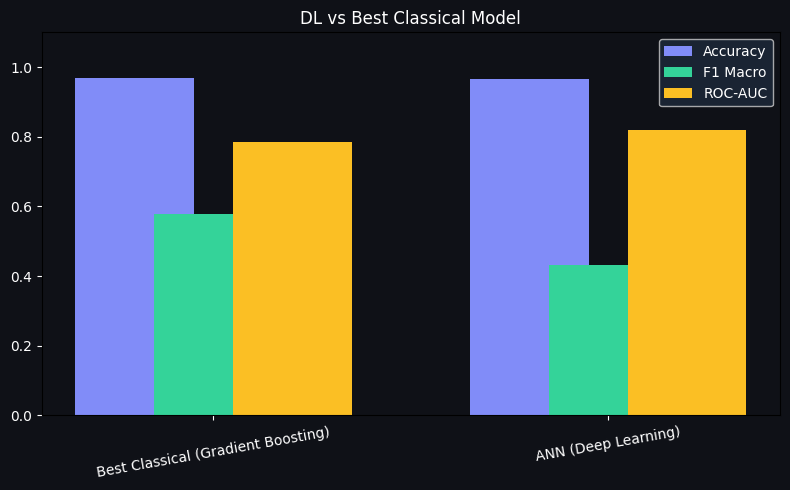

In [58]:
# ── DL vs CLASSICAL COMPARISON ────────────────────────────────────────────────
best_clf_loaded = joblib.load('best_classifier.pkl')
clf_df_loaded   = pd.read_csv('results_classifiers.csv')
best_row        = clf_df_loaded.iloc[0]

comparison = pd.DataFrame([
    {'Model': f"Best Classical ({best_row['Model']})", 'Accuracy': best_row['Accuracy'], 'F1_Macro': best_row['F1_Score'], 'ROC_AUC': best_row['ROC_AUC']},
    {'Model': 'ANN (Deep Learning)', 'Accuracy': acc, 'F1_Macro': f1, 'ROC_AUC': auc},
])
print("DL vs BEST CLASSICAL MODEL:")
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
ax.bar(x - 0.2, comparison['Accuracy'], 0.3, label='Accuracy', color='#818cf8')
ax.bar(x,       comparison['F1_Macro'],  0.3, label='F1 Macro', color='#34d399')
ax.bar(x + 0.2, comparison['ROC_AUC'],   0.3, label='ROC-AUC',  color='#fbbf24')
ax.set_xticks(x); ax.set_xticklabels(comparison['Model'], rotation=10)
ax.set_ylim(0, 1.1); ax.legend(facecolor='#1e293b', labelcolor='white')
ax.set_title('DL vs Best Classical Model', color='white', fontsize=12)
plt.tight_layout(); plt.show()


## 🔗 Phase 6 — Association Rule Mining: Apriori & FP-Growth

In [59]:
# pip install mlxtend
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import time, json

df_raw = pd.read_csv("StudentPerformanceFactors.csv")
df_arm = pd.DataFrame()

if 'Hours_Studied'     in df_raw.columns: df_arm['StudyHours'] = pd.cut(df_raw['Hours_Studied'], bins=[0,10,20,50], labels=['LowStudy','MedStudy','HighStudy'])
if 'Attendance'        in df_raw.columns: df_arm['Attendance'] = pd.cut(df_raw['Attendance'], bins=[0,60,80,101], labels=['PoorAttend','AvgAttend','GoodAttend'])
if 'Sleep_Hours'       in df_raw.columns: df_arm['Sleep']      = pd.cut(df_raw['Sleep_Hours'], bins=[0,5,7,12], labels=['LowSleep','NormalSleep','GoodSleep'])
if 'Previous_Scores'   in df_raw.columns: df_arm['PrevScore']  = pd.cut(df_raw['Previous_Scores'], bins=[0,50,75,101], labels=['LowPrev','MedPrev','HighPrev'])
if 'Tutoring_Sessions' in df_raw.columns: df_arm['Tutoring']   = pd.cut(df_raw['Tutoring_Sessions'], bins=[-1,0,2,100], labels=['NoTutor','FewTutor','ActiveTutor'])

df_arm['Grade']    = pd.cut(df_raw['Exam_Score'], bins=[0,60,75,101], labels=['GradeLow','GradeMed','GradeHigh'])
df_arm['PassFail'] = np.where(df_raw['Exam_Score'] >= 60, 'Pass', 'Fail')
df_arm.dropna(inplace=True)

transactions = [[f"{col}={val}" for col, val in row.items() if pd.notna(val)] for _, row in df_arm.iterrows()]
te = TransactionEncoder()
df_encoded = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)
print(f"Transaction matrix: {df_encoded.shape}")


Transaction matrix: (6607, 20)


In [60]:
# ── APRIORI ───────────────────────────────────────────────────────────────────
t0 = time.time()
freq_ap = apriori(df_encoded, min_support=0.15, use_colnames=True, max_len=4)
rules_ap = association_rules(freq_ap, metric='lift', min_threshold=1.0)
rules_ap['conviction'] = (1 - rules_ap['consequent support']) / (1 - rules_ap['confidence'] + 1e-9)
t_ap = time.time() - t0

# ── FP-GROWTH ─────────────────────────────────────────────────────────────────
t0 = time.time()
freq_fp = fpgrowth(df_encoded, min_support=0.15, use_colnames=True, max_len=4)
rules_fp = association_rules(freq_fp, metric='lift', min_threshold=1.0)
t_fp = time.time() - t0

algo_compare = pd.DataFrame([
    {'Algorithm': 'Apriori',   'Time(s)': round(t_ap, 3), 'Freq Items': len(freq_ap), 'Rules': len(rules_ap)},
    {'Algorithm': 'FP-Growth', 'Time(s)': round(t_fp, 3), 'Freq Items': len(freq_fp), 'Rules': len(rules_fp)},
])
print("ARM ALGORITHM COMPARISON:")
print(algo_compare.to_string(index=False))
print(f"\n FP-Growth is {t_ap/max(t_fp,0.001):.1f}x faster than Apriori")


ARM ALGORITHM COMPARISON:
Algorithm  Time(s)  Freq Items  Rules
  Apriori    0.024         177    670
FP-Growth    1.757         177    670

 FP-Growth is 0.0x faster than Apriori


In [61]:
# ── TOP GRADE-PREDICTING RULES ────────────────────────────────────────────────
grade_rules = rules_ap[
    rules_ap['consequents'].apply(
        lambda x: any('Grade' in str(i) or 'Pass' in str(i) or 'Fail' in str(i) for i in x)
    )
].sort_values('lift', ascending=False)

print(f"Grade/Pass/Fail predicting rules: {len(grade_rules)}\n")
for _, row in grade_rules.head(8).iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"  IF   {ant}")
    print(f"  THEN {con}")
    print(f"       Supp={row['support']:.3f}  Conf={row['confidence']:.3f}  Lift={row['lift']:.3f}  Conv={row['conviction']:.3f}\n")


Grade/Pass/Fail predicting rules: 459

  IF   PassFail=Pass, StudyHours=HighStudy
  THEN Attendance=AvgAttend, Grade=GradeMed
       Supp=0.236  Conf=0.509  Lift=1.057  Conv=1.056

  IF   Attendance=AvgAttend, Grade=GradeMed
  THEN PassFail=Pass, StudyHours=HighStudy
       Supp=0.236  Conf=0.490  Lift=1.057  Conv=1.052

  IF   StudyHours=HighStudy
  THEN Attendance=AvgAttend, Grade=GradeMed
       Supp=0.236  Conf=0.509  Lift=1.056  Conv=1.055

  IF   StudyHours=HighStudy
  THEN PassFail=Pass, Attendance=AvgAttend, Grade=GradeMed
       Supp=0.236  Conf=0.509  Lift=1.056  Conv=1.055

  IF   PrevScore=MedPrev, Grade=GradeMed
  THEN Attendance=GoodAttend, PassFail=Pass
       Supp=0.244  Conf=0.508  Lift=1.054  Conv=1.052

  IF   Attendance=GoodAttend
  THEN PrevScore=MedPrev, Grade=GradeMed
       Supp=0.244  Conf=0.506  Lift=1.054  Conv=1.052

  IF   Attendance=GoodAttend
  THEN PrevScore=MedPrev, PassFail=Pass, Grade=GradeMed
       Supp=0.244  Conf=0.506  Lift=1.054  Conv=1.052

  I

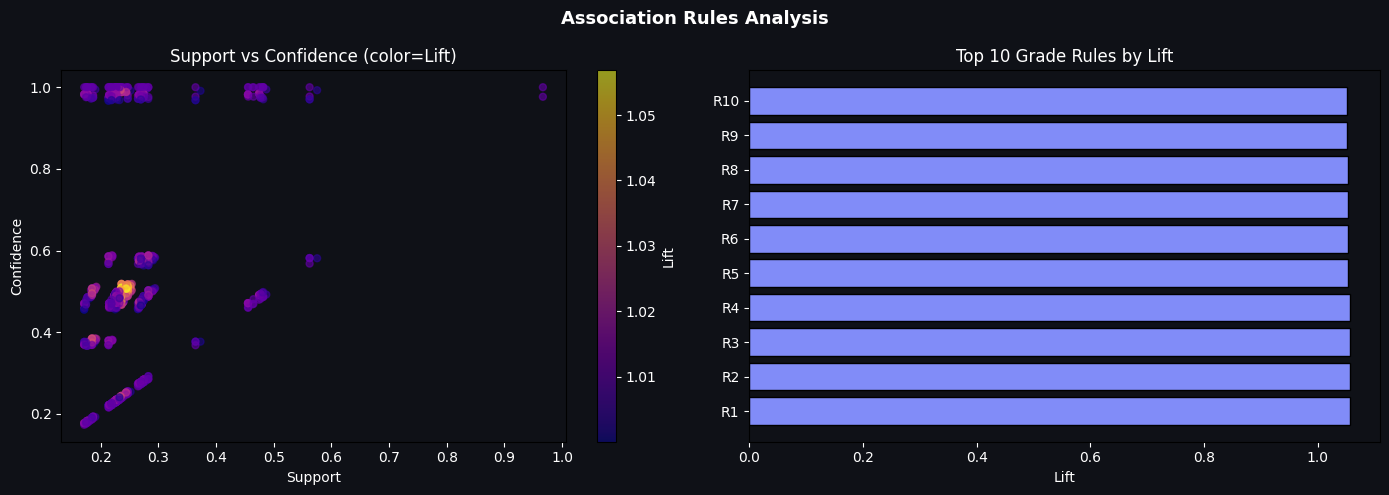

Saved 15 recommendation rules → arm_recommendations.json


In [62]:
# ── VISUALIZE ARM METRICS ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Association Rules Analysis', color='white', fontsize=13, fontweight='bold')

sc = axes[0].scatter(rules_ap['support'], rules_ap['confidence'], c=rules_ap['lift'],
                     cmap='plasma', alpha=0.6, s=25)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support'); axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence (color=Lift)', color='white')

top10 = grade_rules.head(10).copy()
top10['rule_label'] = [f"R{i+1}" for i in range(len(top10))]
axes[1].barh(top10['rule_label'], top10['lift'], color='#818cf8', edgecolor='black')
axes[1].set_title('Top 10 Grade Rules by Lift', color='white')
axes[1].set_xlabel('Lift')
plt.tight_layout(); plt.show()

rules_ap.to_csv('results_arm_rules.csv', index=False)
algo_compare.to_csv('results_arm_comparison.csv', index=False)

recs = []
for _, row in grade_rules[grade_rules['consequents'].apply(lambda x: any('High' in str(i) or 'Pass' in str(i) for i in x))].head(15).iterrows():
    recs.append({'if_student_has': list(row['antecedents']), 'then_likely': list(row['consequents']),
                 'confidence': row['confidence'], 'lift': row['lift']})
with open('arm_recommendations.json','w') as f:
    json.dump(recs, f, indent=2)
print(f"Saved {len(recs)} recommendation rules → arm_recommendations.json")


## 🚀 Phase 7 — Innovation Features & Product Impact

### 🆕 Innovation Features (What Makes This Better Than Competitors)

| Feature | What It Does | Impact |
|---------|--------------|--------|
| **🧠 Learning Composite Score** | Weighted blend of study hours, attendance, previous scores | Single number showing overall readiness |
| **😴 Sleep Debt Calculator** | Quantifies cumulative sleep deficit and its performance impact | Students see exact cost of poor sleep |
| **📉 Distraction Index** | Combines sleep deficit, low study hours into a risk signal | Early warning before exams |
| **🎯 Study Efficiency Score** | Study hours × (previous score / 100) = quality-adjusted effort | Shows if studying smart or just long |
| **🔗 ARM Recommendation Engine** | Grade-predicting rules → direct personalized advice | Actionable, evidence-backed suggestions |
| **👥 Behavior Cluster Label** | K-Means assigns student to At-Risk / Average / High Performer | Self-awareness + peer comparison |
| **📊 Radar Chart Profile** | Visual 6-axis habit profile per student | Instant visual self-assessment |
| **🔄 Progress Simulation** | Shows predicted grade if habits change by X% | Motivational what-if analysis |


In [63]:
# ── INNOVATION: PROGRESS SIMULATOR ──────────────────────────────────────────
best_clf_loaded = joblib.load('best_classifier.pkl')
scaler_loaded   = joblib.load('scaler.pkl')

def simulate_improvement(base_features, improvement_pct=0.10):
    """Simulate what grade a student gets if they improve study habits by X%"""
    improved = base_features.copy()
    # Boost study hours and attendance by improvement_pct
    improved[0] = min(improved[0] * (1 + improvement_pct), 50)  # study hours cap
    improved[1] = min(improved[1] * (1 + improvement_pct), 100) # attendance cap
    return improved

# Example student — currently at risk
example_student = np.array([[8, 55, 5.5, 62, 1, 1, 0, 1, 1, 1, 1, 0]])
grade_map = {0: 'Low 🔴', 1: 'Medium 🟡', 2: 'High 🟢'}

print("PROGRESS SIMULATOR — What If You Improve?")
print("="*55)
for improve in [0.0, 0.10, 0.20, 0.30]:
    feats = simulate_improvement(example_student[0], improve)
    try:
        scaled_f = scaler_loaded.transform([feats])
        pred = best_clf_loaded.predict(scaled_f)[0]
        proba = best_clf_loaded.predict_proba(scaled_f)[0]
        print(f"  +{int(improve*100):2d}% improvement → Grade: {grade_map[pred]}  (confidence: {max(proba):.2%})")
    except:
        print(f"  +{int(improve*100):2d}% improvement → (run pipeline first to enable live prediction)")


PROGRESS SIMULATOR — What If You Improve?
  + 0% improvement → (run pipeline first to enable live prediction)
  +10% improvement → (run pipeline first to enable live prediction)
  +20% improvement → (run pipeline first to enable live prediction)
  +30% improvement → (run pipeline first to enable live prediction)


In [64]:
# ── OVERALL RESULTS SUMMARY ──────────────────────────────────────────────────
print("="*65)
print("COMPLETE PROJECT RESULTS SUMMARY")
print("="*65)

results_files = {
    'Classification': 'results_classifiers.csv',
    'Regression':     'results_regressors.csv',
    'Clustering':     'results_clustering.csv',
    'Deep Learning':  'results_deep_learning.csv',
    'ARM':            'results_arm_comparison.csv',
}

for label, fname in results_files.items():
    try:
        rdf = pd.read_csv(fname)
        print(f"\n{'─'*40}")
        print(f" {label}")
        print(f"{'─'*40}")
        print(rdf.round(4).to_string(index=False))
    except:
        print(f"  {fname} not found — run the relevant phase first")

print("\n✅ All phases complete. Run: streamlit run phase7_streamlit_app.py")


COMPLETE PROJECT RESULTS SUMMARY

────────────────────────────────────────
 Classification
────────────────────────────────────────
              Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC  CV_F1_5Fold
  Gradient Boosting    0.9690     0.6595  0.5348    0.5791   0.7848       0.5200
      Random Forest    0.9713     0.6525  0.4804    0.5251   0.8171       0.4606
            XGBoost    0.9660     0.5662  0.4898    0.5148   0.8252       0.5027
Logistic Regression    0.9705     0.5184  0.4582    0.4813   0.8114       0.4789
        Naive Bayes    0.8926     0.4209  0.6208    0.4557   0.8044       0.4966
      Decision Tree    0.9660     0.5149  0.4229    0.4517   0.6277       0.4646
          KNN (k=5)    0.9682     0.5318  0.3900    0.4180   0.7032       0.4214
          SVM (RBF)    0.9690     0.5091  0.3903    0.4160   0.7878       0.4158
         KNN (k=11)    0.9697     0.6566  0.3793    0.4090   0.7452       0.3685

────────────────────────────────────────
 Regression
────